# New Dataset — Alert Cycle Prediction (Feb11_FD001-style)

This notebook mirrors the structure of **Feb11_FD001.ipynb**, but uses the new CSV files:

- `/mnt/data/Train_Data_CSV.csv`
- `/mnt/data/Test_Data_CSV.csv`

Goal: **select the best (Normalization, Model) combo** (by F1) to predict a binary *warning_flag*, then derive the **predicted alert time** (first time the model predicts warning).

> Tip: If you want a different early-warning definition, change `RUL_THRESHOLD`.

In [3]:
import time
start_time = time.perf_counter()

import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

## 1) Load data

In [5]:
TRAIN_PATH = "Train_Data_CSV.csv"
TEST_PATH  = "Test_Data_CSV.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

#test modification start

# Approach to shift RUL down to zero to increase test quality
shifted_test = test_raw.copy()
shifted_test['RUL'] = shifted_test.groupby('Data_No')['RUL'].transform(lambda x: x - x.min())

shifted_test.to_csv('Shifted_Test_Data.csv', index=False)

#test modification end

# Make sure columns match (test file has a different order)
train_raw.columns = ["Data_No","Differential_pressure","Flow_rate","Time","Dust_feed","RUL","Sampling","Bias_type"]
train_raw = train_raw[["Data_No","Differential_pressure","Flow_rate","Time","Dust_feed","Sampling","RUL","Bias_type"]]

train_raw["split"] = "train"
test_raw["split"]  = "test"

full_raw = pd.concat([train_raw, test_raw], ignore_index=True)
full_raw.to_csv("Full_Data_CSV.csv")
train_raw.to_csv("Train_Data_Fixed.csv")

print("Train shape:", train_raw.shape)
print("Test  shape:", test_raw.shape)
print("All   shape:", full_raw.shape)

Train shape: (42440, 9)
Test  shape: (18855, 9)
All   shape: (61295, 9)


In [6]:
full_raw

,Data_No,Differential_pressure,Flow_rate,Time,Dust_feed,Sampling,RUL,Bias_type,split
0,1,11.017769,34.500433,0.1,177.313137,10,131.1,b,train
1,1,0.000000,61.536411,0.2,177.313137,10,131.0,b,train
2,1,4.055263,72.332438,0.3,177.313137,10,130.9,b,train
3,1,0.000000,77.133230,0.4,177.313137,10,130.8,b,train
4,1,0.000000,79.470820,0.5,177.313137,10,130.7,b,train
...,...,...,...,...,...,...,...,...,...
61290,20,47.872929,83.291640,98.0,59.111492,10,38.6,d,test
61291,20,84.640622,83.255339,98.1,59.111492,10,38.5,d,test
61292,20,30.491800,83.255339,98.2,59.111492,10,38.4,d,test
61293,20,49.044383,83.382416,98.3,59.111492,10,38.3,d,test


## 2) Label engineering: `warning_flag` from RUL

`warning_flag = 1` if `RUL <= RUL_THRESHOLD`.

In this dataset, train RUL values are mostly around `{~59, ~118, ~177}`, so a **threshold near 60** usually creates both classes.

In [7]:

# Flag Config

RUL_THRESHOLD = 40          # <-- change if you want earlier/later warning
INCLUDE_TIME_FEATURE = False  # keep similar to FD001 notebook (exclude 'cycle'/'time')

full_df = full_raw.copy()

full_df["warning_flag"] = (full_df["RUL"] <= RUL_THRESHOLD).astype(int)

print("warning_flag positive rate:")
print("  train:", full_df.loc[full_df["split"]=="train","warning_flag"].mean())
print("  test :", full_df.loc[full_df["split"]=="test", "warning_flag"].mean())

display(full_df[["Data_No","Time","RUL","warning_flag","Bias_type"]].head(10))


warning_flag positive rate:
  train: 0.33070216776625827
  test : 0.14834261469106338


,Data_No,Time,RUL,warning_flag,Bias_type
0,1,0.1,131.1,0,b
1,1,0.2,131.0,0,b
2,1,0.3,130.9,0,b
3,1,0.4,130.8,0,b
4,1,0.5,130.7,0,b
5,1,0.6,130.6,0,b
6,1,0.7,130.5,0,b
7,1,0.8,130.4,0,b
8,1,0.9,130.3,0,b
9,1,1.0,130.2,0,b


## 3) Feature matrix

We mimic Feb11_FD001:

- group column: `Data_No`
- we do **NOT** use `Data_No` or `RUL` or `warning_flag` as features
- `Bias_type` is one-hot encoded

In [8]:
def build_feature_frame(df: pd.DataFrame, include_time: bool = False) -> pd.DataFrame:
    df = df.copy()

    # Fix categorical categories so all dummy columns exist consistently
    cats = sorted(full_df["Bias_type"].dropna().unique().tolist())
    df["Bias_type"] = pd.Categorical(df["Bias_type"], categories=cats)

    base_cols = ["Differential_pressure", "Flow_rate", "Dust_feed", "Sampling"]
    if include_time:
        base_cols = base_cols + ["Time"]

    X_num = df[base_cols].copy()
    X_cat = pd.get_dummies(df["Bias_type"], prefix="Bias_type", dtype=int)

    X = pd.concat([X_num, X_cat], axis=1)
    return X

# Build once using the concatenated data so train/test have identical columns
X_all_df = build_feature_frame(full_df, include_time=INCLUDE_TIME_FEATURE)

feature_cols = list(X_all_df.columns)
print("Number of features:", len(feature_cols))
print("Feature columns:", feature_cols)

# Split back
train_mask = (full_df["split"]=="train")
test_mask  = (full_df["split"]=="test")

X_train = X_all_df.loc[train_mask].values
y_train = full_df.loc[train_mask, "warning_flag"].values
g_train = full_df.loc[train_mask, "Data_No"].values

X_test  = X_all_df.loc[test_mask].values
y_test  = full_df.loc[test_mask, "warning_flag"].values
g_test  = full_df.loc[test_mask, "Data_No"].values


Number of features: 8
Feature columns: ['Differential_pressure', 'Flow_rate', 'Dust_feed', 'Sampling', 'Bias_type_a', 'Bias_type_b', 'Bias_type_c', 'Bias_type_d']


## 4) Models + normalizations to try

Same family as Feb11_FD001 (classification models).

Note: RBF-SVM can be very slow for large datasets; it's omitted here by default.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

scaler_factories = {
    "Z-Score": StandardScaler,
    "MinMax": MinMaxScaler
}

models_clf = {

    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.06, max_depth=5,
         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.2, random_state=40,
         eval_metric="logloss",  # avoids warnings in newer xgboost versions
        tree_method="hist"),
    "LightGBM": LGBMClassifier(objective="binary", n_estimators=100, learning_rate=0.12,
         max_depth=-5, subsample=0.4, colsample_bytree=0.4, reg_lambda=1.2, verbosity=-1, random_state= 40),

    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=40, learning_rate=0.11, subsample=1),

}
#

## 5) GroupKFold CV on **TRAIN** (group = Data_No)

This mirrors the engine-wise splitting in Feb11_FD001 (avoid leakage across the same Data_No).

In [10]:
n_groups = pd.Series(g_train).nunique()
n_splits = min(5, n_groups)  # safety

gkf = GroupKFold(n_splits=n_splits)

rows = []
for scaler_name, scaler_cls in scaler_factories.items():
    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train, groups=g_train), start=1):
        X_tr, X_va = X_train[tr_idx], X_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        scaler = scaler_cls()
        X_tr_s = scaler.fit_transform(X_tr)
        X_va_s = scaler.transform(X_va)

        for model_name, model in models_clf.items():
            clf = clone(model)
            clf.fit(X_tr_s, y_tr)
            y_pred = clf.predict(X_va_s)

            acc = accuracy_score(y_va, y_pred)
            prec, rec, f1, _ = precision_recall_fscore_support(
                y_va, y_pred, average="binary", zero_division=0
            )

            rows.append({
                "fold": fold,
                "Normalization": scaler_name,
                "Model": model_name,
                "accuracy": acc,
                "precision": prec,
                "recall": rec,
                "f1": f1,
            })

cv_results_df = pd.DataFrame(rows)

kfold_summary_df = (
    cv_results_df
    .groupby(["Normalization","Model"], as_index=False)[["accuracy","precision","recall","f1"]]
    .mean()
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

print("GroupKFold summary (best → worst by F1):")
display(kfold_summary_df)


GroupKFold summary (best → worst by F1):


,Normalization,Model,accuracy,precision,recall,f1
0,MinMax,Gradient Boosting,0.903967,0.890050,0.810403,0.847853
1,Z-Score,Gradient Boosting,0.903967,0.890050,0.810403,0.847853
2,MinMax,XGBoost,0.902602,0.897781,0.796366,0.843723
3,Z-Score,XGBoost,0.902602,0.897781,0.796366,0.843723
4,MinMax,LightGBM,0.898263,0.889582,0.790809,0.836470
5,Z-Score,LightGBM,0.897484,0.888239,0.789669,0.835331
6,MinMax,Logistic Regression,0.881340,0.813511,0.851087,0.827063
7,Z-Score,Logistic Regression,0.879194,0.811763,0.848593,0.824309
8,Z-Score,Random Forest,0.875450,0.818407,0.802351,0.808824
9,MinMax,Random Forest,0.875143,0.818642,0.800784,0.808209


## 6) Hold-out validation on TRAIN (GroupShuffleSplit)

This is the fast selection step (still group-wise).

In [11]:
HOLDOUT_TEST_SIZE = 0.2
RANDOM_STATE = 42

gss = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_TEST_SIZE, random_state=RANDOM_STATE)
tr_idx, va_idx = next(gss.split(X_train, y_train, groups=g_train))

X_tr, X_va = X_train[tr_idx], X_train[va_idx]
y_tr, y_va = y_train[tr_idx], y_train[va_idx]

hold_rows = []
for scaler_name, scaler_cls in scaler_factories.items():
    scaler = scaler_cls()
    X_tr_s = scaler.fit_transform(X_tr)
    X_va_s = scaler.transform(X_va)

    for model_name, model in models_clf.items():
        clf = clone(model)
        clf.fit(X_tr_s, y_tr)
        y_pred = clf.predict(X_va_s)

        acc = accuracy_score(y_va, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_va, y_pred, average="binary", zero_division=0
        )

        hold_rows.append({
            "Normalization": scaler_name,
            "Model": model_name,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
        })

holdout_summary_df = (
    pd.DataFrame(hold_rows)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

print("Hold-out summary (best → worst by F1):")
display(holdout_summary_df)

best_holdout = holdout_summary_df.iloc[0].to_dict()
print("\nBest (Hold-out) combo:", best_holdout)


Hold-out summary (best → worst by F1):


,Normalization,Model,accuracy,precision,recall,f1
0,Z-Score,XGBoost,0.935407,0.882253,0.920912,0.901168
1,MinMax,XGBoost,0.935407,0.882253,0.920912,0.901168
2,MinMax,LightGBM,0.935293,0.883259,0.919131,0.900838
3,Z-Score,LightGBM,0.934609,0.881449,0.919131,0.899895
4,Z-Score,Gradient Boosting,0.933128,0.867306,0.933737,0.899297
5,MinMax,Gradient Boosting,0.933128,0.867306,0.933737,0.899297
6,Z-Score,Random Forest,0.925951,0.871768,0.900962,0.886125
7,MinMax,Random Forest,0.925609,0.871379,0.900249,0.885579
8,MinMax,Logistic Regression,0.869332,0.727647,0.945137,0.822253
9,Z-Score,Logistic Regression,0.866712,0.723940,0.942643,0.818942



Best (Hold-out) combo: {'Normalization': 'Z-Score', 'Model': 'XGBoost', 'accuracy': 0.9354066985645934, 'precision': 0.8822525597269625, 'recall': 0.9209120057000356, 'f1': 0.9011678577653826}


# Second Step

## 7) Pick best combo + train on full TRAIN, evaluate on TEST

This is where we actually test generalization on the separate `Test_Data_CSV.csv`.

In [12]:
BEST_SOURCE = "Hold-out"  # "Hold-out" or "GroupKFold"

if BEST_SOURCE == "Hold-out":
    best_row = holdout_summary_df.iloc[0]
else:
    best_row = kfold_summary_df.iloc[0]

best_norm = best_row["Normalization"]
best_model_name = best_row["Model"]

print("Using best combo:")
print("  Normalization:", best_norm)
print("  Model        :", best_model_name)

best_scaler = scaler_factories[best_norm]()
best_model  = clone(models_clf[best_model_name])

# Fit on full TRAIN
X_train_s = best_scaler.fit_transform(X_train)
best_model.fit(X_train_s, y_train)

# Evaluate on TEST
X_test_s = best_scaler.transform(X_test)
y_pred_test = best_model.predict(X_test_s)

acc = accuracy_score(y_test, y_pred_test)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average="binary", zero_division=0)

print("\nTEST metrics:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1       : {f1:.4f}")


Using best combo:
  Normalization: Z-Score
  Model        : XGBoost

TEST metrics:
  Accuracy : 0.8929
  Precision: 0.6261
  Recall   : 0.6904
  F1       : 0.6567


## 8) Confusion matrix on TEST

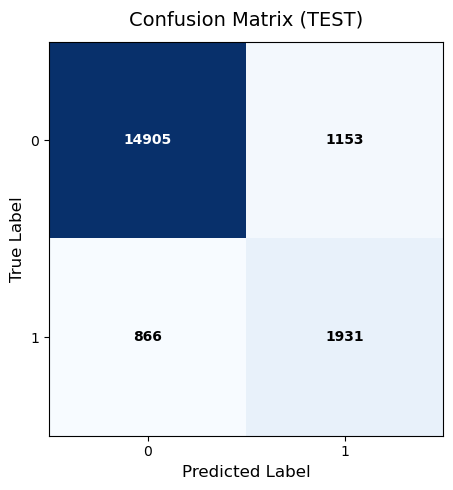

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(
    ax=ax,
    cmap="Blues",         # cleaner than pink/yellow
    colorbar=False,
    values_format="d"      # integer counts
)

# Make cell text easier to read
threshold = cm.max() / 2.0
for text, value in zip(disp.text_.ravel(), cm.ravel()):
    text.set_fontsize(10)
    text.set_fontweight("bold")
    text.set_color("white" if value > threshold else "black")

ax.set_title("Confusion Matrix (TEST)", fontsize=14, pad=12)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.savefig("Newdataset_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


## 9) Predict alert time per Data_No (TEST)

**True alert time**: first `Time` where `warning_flag = 1` (i.e., `RUL <= RUL_THRESHOLD`)  
**Predicted alert time**: first `Time` where predicted probability of warning ≥ `PROBA_THRESHOLD`

This mirrors the “alert cycle” logic in Feb11_FD001.

In [16]:
PROBA_THRESHOLD = 0.75   # usually between 0 and 1

def get_proba_pos(model, X):
    """Return P(y=1). Works for models with predict_proba; falls back to decision_function."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        z = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-z))  # sigmoid (uncalibrated)
    return model.predict(X).astype(float)

# Add predictions back to the TEST dataframe
test_df = full_df.loc[test_mask].copy()
test_df = test_df.sort_values(["Data_No", "Time"]).reset_index(drop=True)

test_proba = get_proba_pos(best_model, X_test_s)
test_df["pred_proba"] = test_proba

# -------------------------------------------------
# Compute Data_No-specific probability statistics
# -------------------------------------------------
proba_stats = (
    test_df.groupby("Data_No")["pred_proba"]
    .agg(
        proba_std="std",
        proba_min="min",
        proba_max="max",
        proba_mean="mean"
    )
    .reset_index()
)

proba_stats["proba_range"] = proba_stats["proba_max"] - proba_stats["proba_min"]

# Data_No-specific threshold:
# threshold_d = min_d + factor * (max_d - min_d)
proba_stats["proba_threshold"] = (
    proba_stats["proba_min"] + PROBA_THRESHOLD * proba_stats["proba_range"]
)

print("Per-Data_No probability stats and thresholds:")
display(proba_stats.sort_values("Data_No"))

# Merge threshold back into test_df
test_df = test_df.merge(
    proba_stats[["Data_No", "proba_threshold"]],
    on="Data_No",
    how="left"
)

# Use group-specific threshold
test_df["pred_warning"] = (
    test_df["pred_proba"] >= test_df["proba_threshold"]
).astype(int)

# -------------------------------------------------
# Drop Data_No groups with nearly-flat probabilities
# -------------------------------------------------
FLAT_STD_THR = 0.20
FLAT_RANGE_THR = 0.50   # scalar threshold on range

flat_data_nos = proba_stats.loc[
    (proba_stats["proba_std"] <= FLAT_STD_THR) |
    (proba_stats["proba_range"] <= FLAT_RANGE_THR),
    "Data_No"
].tolist()

print("Dropped flat Data_No values:")
print(flat_data_nos)
print(f"Number dropped: {len(flat_data_nos)} / {test_df['Data_No'].nunique()}")

# Keep only non-flat groups
test_df_filtered = test_df.loc[~test_df["Data_No"].isin(flat_data_nos)].copy()
test_df_filtered.to_csv("Test_Data_Filtered.csv", index=False)

print("\nPer-Data_No probability variation stats:")
display(proba_stats.sort_values(["proba_std"]))

def first_time_where(df_group, col):
    hit = df_group.loc[df_group[col] == 1, "Time"]
    return float(hit.iloc[0]) if len(hit) > 0 else np.nan

alert_rows = []
for data_no, g in test_df_filtered.groupby("Data_No"):
    true_t = first_time_where(g, "warning_flag")
    pred_t = first_time_where(g, "pred_warning")
    thr_d = g["proba_threshold"].iloc[0]

    alert_rows.append({
        "Data_No": data_no,
        "proba_threshold": thr_d,
        "true_alert_time": true_t,
        "pred_alert_time": pred_t,
        "delta_time(pred-true)": pred_t - true_t if (not np.isnan(true_t) and not np.isnan(pred_t)) else np.nan,
        "has_true_alert": int(not np.isnan(true_t)),
        "has_pred_alert": int(not np.isnan(pred_t)),
    })

alert_table = pd.DataFrame(alert_rows).sort_values("Data_No").reset_index(drop=True)

print("\nPer-Data_No alert time table after dropping flat groups (TEST):")
display(alert_table)

print("\nCoverage / sanity after filtering:")
print("  % groups with true alert:", alert_table["has_true_alert"].mean())
print("  % groups with predicted alert:", alert_table["has_pred_alert"].mean())
print("  mean delta_time (ignoring NaNs):", alert_table["delta_time(pred-true)"].mean())

Per-Data_No probability stats and thresholds:


,Data_No,proba_std,proba_min,proba_max,proba_mean,proba_range,proba_threshold
0,1,0.258595,0.004215,0.948271,0.110713,0.944056,0.712257
1,2,0.285618,0.003764,0.992665,0.192513,0.988901,0.745439
2,3,0.294458,0.005894,0.992250,0.233721,0.986356,0.745661
3,4,0.391748,0.005894,0.993269,0.355875,0.987375,0.746426
4,5,0.366183,0.005894,0.988094,0.280270,0.982200,0.742544
5,6,0.355779,0.005123,0.989463,0.319874,0.984340,0.743378
6,7,0.141036,0.003764,0.523515,0.093841,0.519751,0.393577
7,8,0.236027,0.025348,0.935393,0.243257,0.910045,0.707882
8,9,0.324268,0.011005,0.992501,0.266209,0.981496,0.747127
9,10,0.160848,0.007370,0.919638,0.200372,0.912268,0.691571


Dropped flat Data_No values:
[7, 10, 16, 20]
Number dropped: 4 / 20

Per-Data_No probability variation stats:


,Data_No,proba_std,proba_min,proba_max,proba_mean,proba_range,proba_threshold
19,20,0.058901,0.003764,0.517658,0.030421,0.513894,0.389185
15,16,0.096247,0.003922,0.925627,0.035348,0.921706,0.695201
6,7,0.141036,0.003764,0.523515,0.093841,0.519751,0.393577
9,10,0.160848,0.007370,0.919638,0.200372,0.912268,0.691571
16,17,0.202599,0.005447,0.964524,0.153391,0.959077,0.724755
17,18,0.230581,0.003764,0.959451,0.160871,0.955687,0.720529
11,12,0.233848,0.013234,0.809508,0.158794,0.796274,0.610440
7,8,0.236027,0.025348,0.935393,0.243257,0.910045,0.707882
0,1,0.258595,0.004215,0.948271,0.110713,0.944056,0.712257
18,19,0.283701,0.005123,0.985919,0.213450,0.980796,0.740720



Per-Data_No alert time table after dropping flat groups (TEST):


,Data_No,proba_threshold,true_alert_time,pred_alert_time,delta_time(pred-true),has_true_alert,has_pred_alert
0,1,0.712257,98.1,100.1,2.0,1,1
1,2,0.745439,89.7,86.0,-3.7,1,1
2,3,0.745661,71.3,39.5,-31.8,1,1
3,4,0.746426,89.2,60.8,-28.4,1,1
4,5,0.742544,75.1,69.8,-5.3,1,1
5,6,0.743378,65.6,37.2,-28.4,1,1
6,8,0.707882,89.8,82.8,-7.0,1,1
7,9,0.747127,82.3,78.0,-4.3,1,1
8,11,0.747663,78.4,72.8,-5.6,1,1
9,12,0.610440,72.6,68.1,-4.5,1,1



Coverage / sanity after filtering:
  % groups with true alert: 1.0
  % groups with predicted alert: 1.0
  mean delta_time (ignoring NaNs): -11.31875


## 10) One example timeline plot (TEST)

Pick a `Data_No` from test and visualize:
- true warning_flag vs time
- predicted probability vs time

[ 1  2  3  4  5  6  8  9 11 12 13 14 15 17 18 19]


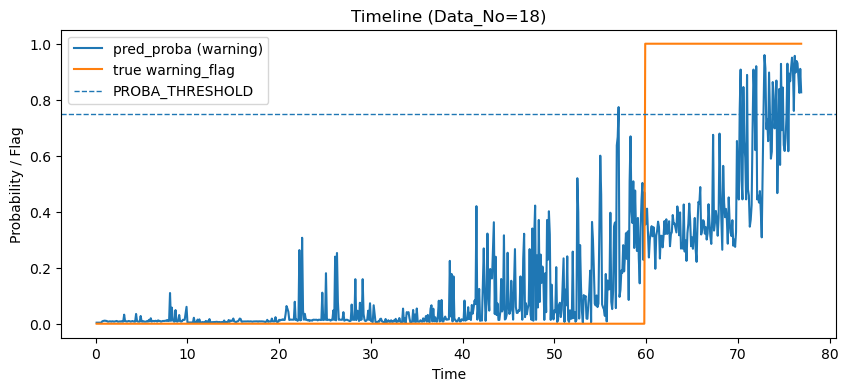

,Time,Differential_pressure,Flow_rate,Dust_feed,Bias_type,RUL,warning_flag,pred_proba,pred_warning
13484,0.1,0.000000,28.951247,59.111492,d,99.8,0,0.003764,0
13485,0.2,0.000000,58.919397,59.111492,d,99.7,0,0.003764,0
13486,0.3,0.000000,71.179699,59.111492,d,99.6,0,0.003764,0
13487,0.4,0.000000,76.955128,59.111492,d,99.5,0,0.003764,0
13488,0.5,1.538619,80.390631,59.111492,d,99.4,0,0.003764,0
13489,0.6,5.531818,81.348116,59.111492,d,99.3,0,0.003764,0
13490,0.7,16.805817,82.261225,59.111492,d,99.2,0,0.008039,0
13491,0.8,0.000000,82.793886,59.111492,d,99.1,0,0.009787,0
13492,0.9,20.081291,83.082867,59.111492,d,99.0,0,0.010516,0
13493,1.0,24.461902,82.946075,59.111492,d,98.9,0,0.011005,0


In [17]:
# Old mapping: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20
# New mapping: 1 2 3 4 5 6 - 7 8 --  9 10 11 12 13 -- 14 15 16 --

# Pick demo only from remaining (non-flat) groups
test_df_filtered = pd.read_csv("Test_Data_Filtered.csv")

remaining_data_nos = test_df_filtered["Data_No"].unique()
print(remaining_data_nos)

show = 14
DEMO_DATA_NO = int(remaining_data_nos[min(show, 15)])

demo = test_df_filtered.loc[test_df_filtered["Data_No"] == DEMO_DATA_NO].copy()

plt.figure(figsize=(10,4))
plt.plot(demo["Time"], demo["pred_proba"], label="pred_proba (warning)")
plt.plot(demo["Time"], demo["warning_flag"], label="true warning_flag")
plt.axhline(PROBA_THRESHOLD, linestyle="--", linewidth=1, label="PROBA_THRESHOLD")
plt.title(f"Timeline (Data_No={DEMO_DATA_NO})")
plt.xlabel("Time")
plt.ylabel("Probability / Flag")
plt.legend()
plt.show()

display(demo[[
    "Time", "Differential_pressure", "Flow_rate", "Dust_feed",
    "Bias_type", "RUL", "warning_flag", "pred_proba", "pred_warning"
]].head(15))

# 1 2 5 6 8 9 11 12 13 15 18 normal
# 3 4 14 17 19 oscillatory
# 7 10 16 20 invalid

## 11) Re-evaluate TEST F1

For some reason not working again if only this cell is being run,
Fixed 09.03

In [18]:
BEST_SOURCE = "Hold-out"  # "Hold-out" or "GroupKFold"

if BEST_SOURCE == "Hold-out":
    best_row = holdout_summary_df.iloc[0]
else:
    best_row = kfold_summary_df.iloc[0]

best_norm = best_row["Normalization"]
best_model_name = best_row["Model"]

print("Using best combo:")
print("  Normalization:", best_norm)
print("  Model        :", best_model_name)

best_scaler = scaler_factories[best_norm]()
best_model  = clone(models_clf[best_model_name])

# ----------------------------------------------------
# Rebuild TEST set from the filtered dataframe created
# in Section 9: test_df_filtered
# ----------------------------------------------------
test_df_filtered = pd.read_csv("Test_Data_Filtered.csv")
filtered_test_df = test_df_filtered.copy().reset_index(drop=True)

X_test_filtered_df = build_feature_frame(filtered_test_df, include_time=INCLUDE_TIME_FEATURE)

# Make sure column order matches training
X_test_filtered_df = X_test_filtered_df.reindex(columns=feature_cols, fill_value=0)

X_test11 = X_test_filtered_df.values
y_test11 = filtered_test_df["warning_flag"].values
g_test11 = filtered_test_df["Data_No"].values

# Fit on full TRAIN
X_train_s = best_scaler.fit_transform(X_train)
best_model.fit(X_train_s, y_train)

# Evaluate on FILTERED TEST
X_test_s11 = best_scaler.transform(X_test11)
y_pred_test11 = best_model.predict(X_test_s11)

acc = accuracy_score(y_test11, y_pred_test11)
prec, rec, f1, _ = precision_recall_fscore_support(y_test11, y_pred_test11, average="binary", zero_division=0)

print("\nFILTERED TEST metrics:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1       : {f1:.4f}")

Using best combo:
  Normalization: Z-Score
  Model        : XGBoost

FILTERED TEST metrics:
  Accuracy : 0.8832
  Precision: 0.6250
  Recall   : 0.7587
  F1       : 0.6854


## 12) Selective Testing

In [19]:
# ============================================================
# 12B) TEST ON A MOVING BRACKET OF THE FILTERED TEST SET
#      + uses FULL TRAIN SET
#      + optional test-group selection
#      + overall + per-Data_No metrics
# ============================================================

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.base import clone
import numpy as np
import pandas as pd

# -----------------------------
# USER CONFIG
# -----------------------------
WINDOW_START_LAST_M = 200   # inclusive start: from last M-th sample
WINDOW_STOP_LAST_N  = 50    # exclusive stop : stop before last N-th sample
STRICT_WINDOW = False

# Optional: test only specific Data_No groups
# Examples:
#   TEST_DATA_NOS = None
#   TEST_DATA_NOS = [12]
#   TEST_DATA_NOS = [12, 15, 18]
TEST_DATA_NOS = None

BEST_SOURCE = "Hold-out"   # "Hold-out" or "GroupKFold"
SHOW_GROUP_CONFUSION = False

# -----------------------------
# sanity checks
# -----------------------------
if WINDOW_START_LAST_M <= 0:
    raise ValueError("WINDOW_START_LAST_M must be a positive integer.")

if WINDOW_STOP_LAST_N < 0:
    raise ValueError("WINDOW_STOP_LAST_N must be >= 0.")

if WINDOW_START_LAST_M <= WINDOW_STOP_LAST_N:
    raise ValueError(
        "WINDOW_START_LAST_M must be > WINDOW_STOP_LAST_N, "
        "so the bracket contains WINDOW_START_LAST_M - WINDOW_STOP_LAST_N rows."
    )

# -----------------------------
# pick best scaler/model
# -----------------------------
if BEST_SOURCE == "Hold-out":
    best_row = holdout_summary_df.iloc[0]
else:
    best_row = kfold_summary_df.iloc[0]

best_norm = best_row["Normalization"]
best_model_name = best_row["Model"]

print("Using best combo:")
print("  Normalization        :", best_norm)
print("  Model                :", best_model_name)
print("  WINDOW_START_LAST_M  :", WINDOW_START_LAST_M)
print("  WINDOW_STOP_LAST_N   :", WINDOW_STOP_LAST_N)
print("  Requested rows/group :", WINDOW_START_LAST_M - WINDOW_STOP_LAST_N)
print("  STRICT_WINDOW        :", STRICT_WINDOW)

best_scaler = scaler_factories[best_norm]()
best_model  = clone(models_clf[best_model_name])

def select_moving_bracket(df_group, start_last_m, stop_last_n, strict=False):
    """
    Keep rows from:
        [last M-th sample, ..., just before last N-th sample]

    If group length is L:
        start_idx = max(0, L - M)
        stop_idx  = max(0, L - N)

    Kept rows are:
        g.iloc[start_idx:stop_idx]

    So if L >= M, total kept rows = M - N.
    """
    g = df_group.sort_values("Time").copy()
    L = len(g)

    if strict and L < start_last_m:
        return g.iloc[0:0].copy()

    start_idx = max(0, L - start_last_m)
    stop_idx  = max(0, L - stop_last_n)

    if stop_idx < start_idx:
        stop_idx = start_idx

    return g.iloc[start_idx:stop_idx].copy()

# ============================================================
# 1) FULL TRAIN SET
# ============================================================
train_df_full = (
    full_df.loc[full_df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

X_train_full_df = build_feature_frame(train_df_full, include_time=INCLUDE_TIME_FEATURE)
X_train_full_df = X_train_full_df.reindex(columns=feature_cols, fill_value=0)

X_train_full = X_train_full_df.values
y_train_full = train_df_full["warning_flag"].values

print("\nTRAIN summary (FULL TRAIN SET):")
print(f"  Rows kept      : {len(train_df_full)}")
print(f"  Data_No groups : {train_df_full['Data_No'].nunique()}")

# ============================================================
# 2) TEST SET SELECTION FROM FILTERED TEST SET
# ============================================================
filtered_test_df = test_df_filtered.copy().reset_index(drop=True)

available_test_groups = sorted(filtered_test_df["Data_No"].unique().tolist())

if TEST_DATA_NOS is None:
    selected_test_groups = available_test_groups
else:
    if np.isscalar(TEST_DATA_NOS):
        TEST_DATA_NOS = [TEST_DATA_NOS]

    selected_test_groups = sorted([g for g in TEST_DATA_NOS if g in available_test_groups])

    missing_test = sorted(set(TEST_DATA_NOS) - set(selected_test_groups))
    if len(missing_test) > 0:
        print("Warning: these TEST Data_No values were not found in test_df_filtered and will be ignored:")
        print(missing_test)

    if len(selected_test_groups) == 0:
        raise ValueError("No valid TEST Data_No values remain after filtering.")

test_df_selected = filtered_test_df.loc[
    filtered_test_df["Data_No"].isin(selected_test_groups)
].copy()

# Save original group lengths before windowing
test_group_lengths = (
    test_df_selected.groupby("Data_No")
    .size()
    .reset_index(name="group_total_rows_before_window")
)

# Apply moving bracket per Data_No
limited_test_df = (
    test_df_selected
    .sort_values(["Data_No", "Time"])
    .groupby("Data_No", group_keys=False)
    .apply(
        lambda g: select_moving_bracket(
            g,
            start_last_m=WINDOW_START_LAST_M,
            stop_last_n=WINDOW_STOP_LAST_N,
            strict=STRICT_WINDOW
        )
    )
    .reset_index(drop=True)
)

print("\nTEST selection summary:")
print(f"  Filtered test rows before selection   : {len(filtered_test_df)}")
print(f"  Rows after Data_No selection          : {len(test_df_selected)}")
print(f"  Rows after moving-bracket filtering   : {len(limited_test_df)}")
print(f"  Data_No groups tested                 : {limited_test_df['Data_No'].nunique()}")
print(f"  Requested rows per full-length group  : {WINDOW_START_LAST_M - WINDOW_STOP_LAST_N}")

rows_kept_table = (
    limited_test_df.groupby("Data_No")
    .agg(
        rows_kept=("Data_No", "size"),
        time_min=("Time", "min"),
        time_max=("Time", "max")
    )
    .reset_index()
    .sort_values("Data_No")
    .reset_index(drop=True)
)

rows_kept_table["requested_rows_if_full_length"] = WINDOW_START_LAST_M - WINDOW_STOP_LAST_N

print("\nRows kept per Data_No:")
display(rows_kept_table)

# ============================================================
# 3) BUILD TEST FEATURES
# ============================================================
X_test_limited_df = build_feature_frame(limited_test_df, include_time=INCLUDE_TIME_FEATURE)
X_test_limited_df = X_test_limited_df.reindex(columns=feature_cols, fill_value=0)

X_test_limited = X_test_limited_df.values
y_test_limited = limited_test_df["warning_flag"].values
g_test_limited = limited_test_df["Data_No"].values

# ============================================================
# 4) TRAIN ON FULL TRAIN SET + PREDICT
# ============================================================
X_train_full_s = best_scaler.fit_transform(X_train_full)
best_model.fit(X_train_full_s, y_train_full)

X_test_limited_s = best_scaler.transform(X_test_limited)
y_pred_limited = best_model.predict(X_test_limited_s)

def get_proba_pos_local(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        z = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-z))
    return model.predict(X).astype(float)

y_proba_limited = get_proba_pos_local(best_model, X_test_limited_s)

# ============================================================
# 5) OVERALL METRICS
# ============================================================
acc = accuracy_score(y_test_limited, y_pred_limited)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test_limited, y_pred_limited, average="binary", zero_division=0
)

cm = confusion_matrix(y_test_limited, y_pred_limited)

print("\nOVERALL metrics on selected moving-bracket filtered TEST set:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1       : {f1:.4f}")
print("  Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

# ============================================================
# 6) ATTACH PREDICTIONS BACK
# ============================================================
limited_test_results = limited_test_df.copy()
limited_test_results["y_pred"] = y_pred_limited
limited_test_results["pred_proba"] = y_proba_limited

# ============================================================
# 7) PER-Data_No METRICS + WINDOW/BRACKET INFO
# ============================================================
group_metric_rows = []
group_range_rows = []

for data_no, g in limited_test_results.groupby("Data_No"):
    y_true_g = g["warning_flag"].values
    y_pred_g = g["y_pred"].values

    acc_g = accuracy_score(y_true_g, y_pred_g)
    prec_g, rec_g, f1_g, _ = precision_recall_fscore_support(
        y_true_g, y_pred_g, average="binary", zero_division=0
    )

    pos_rate_g = np.mean(y_true_g)

    def first_time_where(df_group, col):
        hit = df_group.loc[df_group[col] == 1, "Time"]
        return float(hit.iloc[0]) if len(hit) > 0 else np.nan

    true_alert_t = first_time_where(g, "warning_flag")
    pred_alert_t = first_time_where(g, "y_pred")

    total_len = int(
        test_group_lengths.loc[
            test_group_lengths["Data_No"] == data_no,
            "group_total_rows_before_window"
        ].iloc[0]
    )

    actual_rows_kept = len(g)

    if actual_rows_kept > 0:
        effective_start_last = min(WINDOW_START_LAST_M, total_len)
        effective_stop_last_exclusive = min(WINDOW_STOP_LAST_N, total_len)
        effective_end_last_inclusive = effective_stop_last_exclusive + 1
    else:
        effective_start_last = np.nan
        effective_stop_last_exclusive = np.nan
        effective_end_last_inclusive = np.nan

    row = {
        "Data_No": data_no,
        "n_rows": actual_rows_kept,
        "time_min": g["Time"].min(),
        "time_max": g["Time"].max(),
        "positive_rate": pos_rate_g,
        "accuracy": acc_g,
        "precision": prec_g,
        "recall": rec_g,
        "f1": f1_g,
    }

    row2 = {
        "Data_No": data_no,
        "total_rows_before_window": total_len,
        "requested_window_label": f"last_{WINDOW_START_LAST_M}_to_before_last_{WINDOW_STOP_LAST_N}",
        "actual_start_last": effective_start_last,
        "actual_end_last_inclusive": effective_end_last_inclusive,
        "actual_rows_kept": actual_rows_kept,
        "true_alert_time": true_alert_t,
        "pred_alert_time": pred_alert_t,
        "delta_time(pred-true)": (
            pred_alert_t - true_alert_t
            if (not np.isnan(true_alert_t) and not np.isnan(pred_alert_t))
            else np.nan
        ),
        "mean_pred_proba": g["pred_proba"].mean(),
        "max_pred_proba": g["pred_proba"].max(),
        "min_pred_proba": g["pred_proba"].min(),
    }

    if SHOW_GROUP_CONFUSION:
        cm_g = confusion_matrix(y_true_g, y_pred_g, labels=[0, 1])
        row["TN"] = cm_g[0, 0]
        row["FP"] = cm_g[0, 1]
        row["FN"] = cm_g[1, 0]
        row["TP"] = cm_g[1, 1]

    group_metric_rows.append(row)
    group_range_rows.append(row2)

per_data_no_metrics = (
    pd.DataFrame(group_metric_rows)
    .sort_values("Data_No")
    .reset_index(drop=True)
)

per_data_no_metrics2 = (
    pd.DataFrame(group_range_rows)
    .sort_values("Data_No")
    .reset_index(drop=True)
)

print("\nPer-Data_No metrics:")
display(per_data_no_metrics)

print("\nPer-Data_No window/range metrics:")
display(per_data_no_metrics2)

# ============================================================
# 8) PREVIEW RESULTS
# ============================================================
print("\nPreview of row-level limited test results:")
display(
    limited_test_results[
        ["Data_No", "Time", "RUL", "warning_flag", "y_pred", "pred_proba"]
    ].sort_values(["Data_No", "Time"]).head(30)
)

# Old mapping: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20
# New mapping: 1 2 3 4 5 6 - 7 8 --  9 10 11 12 13 -- 14 15 16 --


from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.base import clone
import numpy as np
import pandas as pd

# -----------------------------
# USER CONFIG
# -----------------------------
WINDOW_START_LAST_M = 200   # inclusive start: from last M-th sample
WINDOW_STOP_LAST_N  = 50    # exclusive stop : stop before last N-th sample
STRICT_WINDOW = False

# Optional: test only specific Data_No groups
# Examples:
#   TEST_DATA_NOS = None
#   TEST_DATA_NOS = [12]
#   TEST_DATA_NOS = [12, 15, 18]
TEST_DATA_NOS = None

BEST_SOURCE = "Hold-out"   # "Hold-out" or "GroupKFold"
SHOW_GROUP_CONFUSION = False

# -----------------------------
# sanity checks
# -----------------------------
if WINDOW_START_LAST_M <= 0:
    raise ValueError("WINDOW_START_LAST_M must be a positive integer.")

if WINDOW_STOP_LAST_N < 0:
    raise ValueError("WINDOW_STOP_LAST_N must be >= 0.")

if WINDOW_START_LAST_M <= WINDOW_STOP_LAST_N:
    raise ValueError(
        "WINDOW_START_LAST_M must be > WINDOW_STOP_LAST_N, "
        "so the bracket contains WINDOW_START_LAST_M - WINDOW_STOP_LAST_N rows."
    )

# -----------------------------
# pick best scaler/model
# -----------------------------
if BEST_SOURCE == "Hold-out":
    best_row = holdout_summary_df.iloc[0]
else:
    best_row = kfold_summary_df.iloc[0]

best_norm = best_row["Normalization"]
best_model_name = best_row["Model"]

print("Using best combo:")
print("  Normalization        :", best_norm)
print("  Model                :", best_model_name)
print("  WINDOW_START_LAST_M  :", WINDOW_START_LAST_M)
print("  WINDOW_STOP_LAST_N   :", WINDOW_STOP_LAST_N)
print("  Requested rows/group :", WINDOW_START_LAST_M - WINDOW_STOP_LAST_N)
print("  STRICT_WINDOW        :", STRICT_WINDOW)

best_scaler = scaler_factories[best_norm]()
best_model  = clone(models_clf[best_model_name])

def select_moving_bracket(df_group, start_last_m, stop_last_n, strict=False):
    """
    Keep rows from:
        [last M-th sample, ..., just before last N-th sample]

    If group length is L:
        start_idx = max(0, L - M)
        stop_idx  = max(0, L - N)

    Kept rows are:
        g.iloc[start_idx:stop_idx]

    So if L >= M, total kept rows = M - N.
    """
    g = df_group.sort_values("Time").copy()
    L = len(g)

    if strict and L < start_last_m:
        return g.iloc[0:0].copy()

    start_idx = max(0, L - start_last_m)
    stop_idx  = max(0, L - stop_last_n)

    if stop_idx < start_idx:
        stop_idx = start_idx

    return g.iloc[start_idx:stop_idx].copy()

# ============================================================
# 1) FULL TRAIN SET
# ============================================================
train_df_full = (
    full_df.loc[full_df["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

X_train_full_df = build_feature_frame(train_df_full, include_time=INCLUDE_TIME_FEATURE)
X_train_full_df = X_train_full_df.reindex(columns=feature_cols, fill_value=0)

X_train_full = X_train_full_df.values
y_train_full = train_df_full["warning_flag"].values

print("\nTRAIN summary (FULL TRAIN SET):")
print(f"  Rows kept      : {len(train_df_full)}")
print(f"  Data_No groups : {train_df_full['Data_No'].nunique()}")

# ============================================================
# 2) TEST SET SELECTION FROM FILTERED TEST SET
# ============================================================
filtered_test_df = test_df_filtered.copy().reset_index(drop=True)

available_test_groups = sorted(filtered_test_df["Data_No"].unique().tolist())

if TEST_DATA_NOS is None:
    selected_test_groups = available_test_groups
else:
    if np.isscalar(TEST_DATA_NOS):
        TEST_DATA_NOS = [TEST_DATA_NOS]

    selected_test_groups = sorted([g for g in TEST_DATA_NOS if g in available_test_groups])

    missing_test = sorted(set(TEST_DATA_NOS) - set(selected_test_groups))
    if len(missing_test) > 0:
        print("Warning: these TEST Data_No values were not found in test_df_filtered and will be ignored:")
        print(missing_test)

    if len(selected_test_groups) == 0:
        raise ValueError("No valid TEST Data_No values remain after filtering.")

test_df_selected = filtered_test_df.loc[
    filtered_test_df["Data_No"].isin(selected_test_groups)
].copy()

# Save original group lengths before windowing
test_group_lengths = (
    test_df_selected.groupby("Data_No")
    .size()
    .reset_index(name="group_total_rows_before_window")
)

# Apply moving bracket per Data_No
limited_test_df = (
    test_df_selected
    .sort_values(["Data_No", "Time"])
    .groupby("Data_No", group_keys=False)
    .apply(
        lambda g: select_moving_bracket(
            g,
            start_last_m=WINDOW_START_LAST_M,
            stop_last_n=WINDOW_STOP_LAST_N,
            strict=STRICT_WINDOW
        )
    )
    .reset_index(drop=True)
)

print("\nTEST selection summary:")
print(f"  Filtered test rows before selection   : {len(filtered_test_df)}")
print(f"  Rows after Data_No selection          : {len(test_df_selected)}")
print(f"  Rows after moving-bracket filtering   : {len(limited_test_df)}")
print(f"  Data_No groups tested                 : {limited_test_df['Data_No'].nunique()}")
print(f"  Requested rows per full-length group  : {WINDOW_START_LAST_M - WINDOW_STOP_LAST_N}")

rows_kept_table = (
    limited_test_df.groupby("Data_No")
    .agg(
        rows_kept=("Data_No", "size"),
        time_min=("Time", "min"),
        time_max=("Time", "max")
    )
    .reset_index()
    .sort_values("Data_No")
    .reset_index(drop=True)
)

rows_kept_table["requested_rows_if_full_length"] = WINDOW_START_LAST_M - WINDOW_STOP_LAST_N

print("\nRows kept per Data_No:")
display(rows_kept_table)

# ============================================================
# 3) BUILD TEST FEATURES
# ============================================================
X_test_limited_df = build_feature_frame(limited_test_df, include_time=INCLUDE_TIME_FEATURE)
X_test_limited_df = X_test_limited_df.reindex(columns=feature_cols, fill_value=0)

X_test_limited = X_test_limited_df.values
y_test_limited = limited_test_df["warning_flag"].values
g_test_limited = limited_test_df["Data_No"].values

# ============================================================
# 4) TRAIN ON FULL TRAIN SET + PREDICT
# ============================================================
X_train_full_s = best_scaler.fit_transform(X_train_full)
best_model.fit(X_train_full_s, y_train_full)

X_test_limited_s = best_scaler.transform(X_test_limited)
y_pred_limited = best_model.predict(X_test_limited_s)

def get_proba_pos_local(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        z = model.decision_function(X)
        return 1.0 / (1.0 + np.exp(-z))
    return model.predict(X).astype(float)

y_proba_limited = get_proba_pos_local(best_model, X_test_limited_s)

# ============================================================
# 5) OVERALL METRICS
# ============================================================
acc = accuracy_score(y_test_limited, y_pred_limited)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test_limited, y_pred_limited, average="binary", zero_division=0
)

cm = confusion_matrix(y_test_limited, y_pred_limited)

print("\nOVERALL metrics on selected moving-bracket filtered TEST set:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1       : {f1:.4f}")
print("  Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

# ============================================================
# 6) ATTACH PREDICTIONS BACK
# ============================================================
limited_test_results = limited_test_df.copy()
limited_test_results["y_pred"] = y_pred_limited
limited_test_results["pred_proba"] = y_proba_limited

# ============================================================
# 7) PER-Data_No METRICS + WINDOW/BRACKET INFO
# ============================================================
group_metric_rows = []
group_range_rows = []

for data_no, g in limited_test_results.groupby("Data_No"):
    y_true_g = g["warning_flag"].values
    y_pred_g = g["y_pred"].values

    acc_g = accuracy_score(y_true_g, y_pred_g)
    prec_g, rec_g, f1_g, _ = precision_recall_fscore_support(
        y_true_g, y_pred_g, average="binary", zero_division=0
    )

    pos_rate_g = np.mean(y_true_g)

    def first_time_where(df_group, col):
        hit = df_group.loc[df_group[col] == 1, "Time"]
        return float(hit.iloc[0]) if len(hit) > 0 else np.nan

    true_alert_t = first_time_where(g, "warning_flag")
    pred_alert_t = first_time_where(g, "y_pred")

    total_len = int(
        test_group_lengths.loc[
            test_group_lengths["Data_No"] == data_no,
            "group_total_rows_before_window"
        ].iloc[0]
    )

    actual_rows_kept = len(g)

    if actual_rows_kept > 0:
        effective_start_last = min(WINDOW_START_LAST_M, total_len)
        effective_stop_last_exclusive = min(WINDOW_STOP_LAST_N, total_len)
        effective_end_last_inclusive = effective_stop_last_exclusive + 1
    else:
        effective_start_last = np.nan
        effective_stop_last_exclusive = np.nan
        effective_end_last_inclusive = np.nan

    row = {
        "Data_No": data_no,
        "n_rows": actual_rows_kept,
        "time_min": g["Time"].min(),
        "time_max": g["Time"].max(),
        "positive_rate": pos_rate_g,
        "accuracy": acc_g,
        "precision": prec_g,
        "recall": rec_g,
        "f1": f1_g,
    }

    row2 = {
        "Data_No": data_no,
        "total_rows_before_window": total_len,
        "requested_window_label": f"last_{WINDOW_START_LAST_M}_to_before_last_{WINDOW_STOP_LAST_N}",
        "actual_start_last": effective_start_last,
        "actual_end_last_inclusive": effective_end_last_inclusive,
        "actual_rows_kept": actual_rows_kept,
        "true_alert_time": true_alert_t,
        "pred_alert_time": pred_alert_t,
        "delta_time(pred-true)": (
            pred_alert_t - true_alert_t
            if (not np.isnan(true_alert_t) and not np.isnan(pred_alert_t))
            else np.nan
        ),
        "mean_pred_proba": g["pred_proba"].mean(),
        "max_pred_proba": g["pred_proba"].max(),
        "min_pred_proba": g["pred_proba"].min(),
    }

    if SHOW_GROUP_CONFUSION:
        cm_g = confusion_matrix(y_true_g, y_pred_g, labels=[0, 1])
        row["TN"] = cm_g[0, 0]
        row["FP"] = cm_g[0, 1]
        row["FN"] = cm_g[1, 0]
        row["TP"] = cm_g[1, 1]

    group_metric_rows.append(row)
    group_range_rows.append(row2)

per_data_no_metrics = (
    pd.DataFrame(group_metric_rows)
    .sort_values("Data_No")
    .reset_index(drop=True)
)

per_data_no_metrics2 = (
    pd.DataFrame(group_range_rows)
    .sort_values("Data_No")
    .reset_index(drop=True)
)

print("\nPer-Data_No metrics:")
display(per_data_no_metrics)

print("\nPer-Data_No window/range metrics:")
display(per_data_no_metrics2)

# ============================================================
# 8) PREVIEW RESULTS
# ============================================================
print("\nPreview of row-level limited test results:")
display(
    limited_test_results[
        ["Data_No", "Time", "RUL", "warning_flag", "y_pred", "pred_proba"]
    ].sort_values(["Data_No", "Time"]).head(30)
)

Using best combo:
  Normalization        : Z-Score
  Model                : XGBoost
  WINDOW_START_LAST_M  : 200
  WINDOW_STOP_LAST_N   : 50
  Requested rows/group : 150
  STRICT_WINDOW        : False

TRAIN summary (FULL TRAIN SET):
  Rows kept      : 42440
  Data_No groups : 35

TEST selection summary:
  Filtered test rows before selection   : 15030
  Rows after Data_No selection          : 15030
  Rows after moving-bracket filtering   : 2400
  Data_No groups tested                 : 16
  Requested rows per full-length group  : 150

Rows kept per Data_No:


,Data_No,rows_kept,time_min,time_max,requested_rows_if_full_length
0,1,150,92.0,106.9,150
1,2,150,83.9,98.8,150
2,3,150,70.3,85.2,150
3,4,150,88.6,103.5,150
4,5,150,71.0,85.9,150
5,6,150,65.6,80.5,150
6,8,150,73.6,88.5,150
7,9,150,80.4,95.3,150
8,11,150,74.8,89.7,150
9,12,150,61.2,76.1,150



OVERALL metrics on selected moving-bracket filtered TEST set:
  Accuracy : 0.6162
  Precision: 0.7507
  Recall   : 0.6789
  F1       : 0.7130
  Confusion matrix [[TN, FP], [FN, TP]]:
[[ 335  380]
 [ 541 1144]]

Per-Data_No metrics:


,Data_No,n_rows,time_min,time_max,positive_rate,accuracy,precision,recall,f1
0,1,150,92.0,106.9,0.593333,0.800000,1.000000,0.662921,0.797297
1,2,150,83.9,98.8,0.613333,0.820000,0.865169,0.836957,0.850829
2,3,150,70.3,85.2,0.933333,0.206667,1.000000,0.150000,0.260870
3,4,150,88.6,103.5,0.960000,0.960000,0.960000,1.000000,0.979592
4,5,150,71.0,85.9,0.726667,0.726667,0.726667,1.000000,0.841699
5,6,150,65.6,80.5,1.000000,0.680000,1.000000,0.680000,0.809524
6,8,150,73.6,88.5,0.000000,0.546667,0.000000,0.000000,0.000000
7,9,150,80.4,95.3,0.873333,0.866667,0.888112,0.969466,0.927007
8,11,150,74.8,89.7,0.760000,0.800000,0.800000,0.982456,0.881890
9,12,150,61.2,76.1,0.240000,0.766667,0.507246,0.972222,0.666667



Per-Data_No window/range metrics:


...

,Data_No,n_rows,time_min,time_max,positive_rate,accuracy,precision,recall,f1
0,1,150,92.0,106.9,0.593333,0.800000,1.000000,0.662921,0.797297
1,2,150,83.9,98.8,0.613333,0.820000,0.865169,0.836957,0.850829
2,3,150,70.3,85.2,0.933333,0.206667,1.000000,0.150000,0.260870
3,4,150,88.6,103.5,0.960000,0.960000,0.960000,1.000000,0.979592
4,5,150,71.0,85.9,0.726667,0.726667,0.726667,1.000000,0.841699
5,6,150,65.6,80.5,1.000000,0.680000,1.000000,0.680000,0.809524
6,8,150,73.6,88.5,0.000000,0.546667,0.000000,0.000000,0.000000
7,9,150,80.4,95.3,0.873333,0.866667,0.888112,0.969466,0.927007
8,11,150,74.8,89.7,0.760000,0.800000,0.800000,0.982456,0.881890
9,12,150,61.2,76.1,0.240000,0.766667,0.507246,0.972222,0.666667



Per-Data_No window/range metrics:


,Data_No,total_rows_before_window,requested_window_label,actual_start_last,actual_end_last_inclusive,actual_rows_kept,true_alert_time,pred_alert_time,delta_time(pred-true),mean_pred_proba,max_pred_proba,min_pred_proba
0,1,1119,last_200_to_before_last_50,200,51,150,98.1,100.0,1.9,0.412835,0.939741,0.019619
1,2,1038,last_200_to_before_last_50,200,51,150,89.7,85.2,-4.5,0.592362,0.984851,0.044112
2,3,902,last_200_to_before_last_50,200,51,150,71.3,71.4,0.1,0.329505,0.907233,0.107390
3,4,1085,last_200_to_before_last_50,200,51,150,89.2,88.6,-0.6,0.952488,0.992699,0.821290
4,5,909,last_200_to_before_last_50,200,51,150,75.1,71.0,-4.1,0.910843,0.985835,0.698433
5,6,855,last_200_to_before_last_50,200,51,150,65.6,65.6,0.0,0.680693,0.989463,0.158261
6,8,935,last_200_to_before_last_50,200,51,150,NaN,79.0,NaN,0.525324,0.892491,0.232685
7,9,1003,last_200_to_before_last_50,200,51,150,82.3,80.4,-1.9,0.807875,0.990784,0.388884
8,11,947,last_200_to_before_last_50,200,51,150,78.4,74.9,-3.5,0.825040,0.986834,0.300712
9,12,811,last_200_to_before_last_50,200,51,150,72.6,68.1,-4.5,0.396275,0.809508,0.059044



Preview of row-level limited test results:


,Data_No,Time,RUL,warning_flag,y_pred,pred_proba
0,1,92.0,46.1,0,0,0.086248
1,1,92.1,46.0,0,0,0.056748
2,1,92.2,45.9,0,0,0.106831
3,1,92.3,45.8,0,0,0.077401
4,1,92.4,45.7,0,0,0.045402
5,1,92.5,45.6,0,0,0.038299
6,1,92.6,45.5,0,0,0.042723
7,1,92.7,45.4,0,0,0.029472
8,1,92.8,45.3,0,0,0.019619
9,1,92.9,45.2,0,0,0.038299


In [20]:
elapsed = time.perf_counter() - start_time
print(f"Total runtime: {elapsed:.2f} s")


Total runtime: 390.85 s


# Score
1. si verdiğimiz değerlere göre buluyor 2. si en optimal değerleri buluyor

In [21]:
import numpy as np
import pandas as pd
from sklearn.base import clone

# 1) BÖLGELİ (ZONED) ASİMETRİK SKOR FONKSİYONU
def calculate_zoned_score(true_alerts, pred_alerts, tol=5.0, miss_penalty=500.0):
    """
    Tahmin farkını 4 bölgeye ayırır:
    - Tol_Early : Kabul edilebilir erken (-tol <= d < 0)
    - Tol_Late  : Kabul edilebilir geç  (0 <= d <= tol)
    - Far_Early : Çok erken (d < -tol)
    - Far_Late  : Çok geç   (d > tol)
    """
    d = np.asarray(pred_alerts) - np.asarray(true_alerts)
    
    valid_mask = ~np.isnan(d)
    d_valid = d[valid_mask]
    
    # 4 Bölgenin Maskeleri
    mask_tol_early = (d_valid >= -tol) & (d_valid < 0)
    mask_tol_late  = (d_valid >= 0) & (d_valid <= tol)
    mask_far_early = (d_valid < -tol)
    mask_far_late  = (d_valid > tol)
    
    # Zaman Sabitleri
    T_tol_early = 15.0  # En hafif ceza
    T_tol_late  = 10.0  # Erken olmaya göre daha ağır ceza
    T_far_early = 7.0   # Tolerans dışı erken
    T_far_late  = 4.0   # Tolerans dışı geç (EN AĞIR CEZA)
    
    # Cezaların Hesaplanması
    scores = np.zeros_like(d_valid, dtype=float)
    scores[mask_tol_early] = np.exp(-d_valid[mask_tol_early] / T_tol_early) - 1
    scores[mask_tol_late]  = np.exp(d_valid[mask_tol_late] / T_tol_late) - 1
    scores[mask_far_early] = np.exp(-d_valid[mask_far_early] / T_far_early) - 1
    scores[mask_far_late]  = np.exp(d_valid[mask_far_late] / T_far_late) - 1
    
    total_score = float(np.sum(scores))
    
    missed_alerts = int(np.isnan(d).sum())
    total_score += missed_alerts * miss_penalty 
    
    N = len(d_valid) if len(d_valid) > 0 else 1
    
    return {
        "Score": total_score,
        "MAE": float(np.mean(np.abs(d_valid))) if len(d_valid) > 0 else np.nan,
        "Missed_Alerts": missed_alerts,
        "Tol_Early_Rate": float(np.sum(mask_tol_early)) / N,
        "Tol_Late_Rate": float(np.sum(mask_tol_late)) / N,
        "Far_Early_Rate": float(np.sum(mask_far_early)) / N,
        "Far_Late_Rate": float(np.sum(mask_far_late)) / N
    }

# 2) MODELLERİN DEĞERLENDİRİLMESİ
print("Modeller Bölgesel Skorlama ve Peş Peşe Uyarı (Consecutive Hits) Mantığına Göre Değerlendiriliyor...\n")

scoring_results = []
PROBA_THRESHOLD = 0.5      # Uyarı tetikleme eşiği
CONSECUTIVE_HITS = 2        # (YENİ) Peş peşe kaç kez uyarı vermesi gerekiyor (FD001'deki K değeri)
MY_TOLERANCE = 10.0          # Tolerans penceresi

t_test = full_df.loc[full_df["split"] == "test", "Time"].values

for scaler_name, scaler_cls in scaler_factories.items():
    scaler = scaler_cls()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    for model_name, model in models_clf.items():
        reg = clone(model)
        reg.fit(X_train_s, y_train)
        
        if hasattr(reg, "predict_proba"):
            test_proba = reg.predict_proba(X_test_s)[:, 1]
        elif hasattr(reg, "decision_function"):
            z = reg.decision_function(X_test_s)
            test_proba = 1.0 / (1.0 + np.exp(-z))
        else:
            test_proba = reg.predict(X_test_s).astype(float)
            
        test_df_eval = pd.DataFrame({
            "Data_No": g_test,
            "Time": t_test,
            "warning_flag": y_test,
            "pred_proba": test_proba
        })
        
        test_df_eval["pred_warning"] = (test_df_eval["pred_proba"] >= PROBA_THRESHOLD).astype(int)
        
        true_alerts = []
        pred_alerts = []
        
        for data_no, g in test_df_eval.groupby("Data_No"):
            g = g.sort_values("Time")
            
            # Gerçek uyarı zamanı
            t_true = g.loc[g["warning_flag"] == 1, "Time"]
            true_c = float(t_true.iloc[0]) if len(t_true) > 0 else np.nan
            
            # (YENİ) Tahmin edilen zamanı Kurala (Peş Peşe Vuruş) göre bulma
            pred_c = np.nan
            hit_streak = 0
            times = g["Time"].values
            warnings = g["pred_warning"].values
            
            for i in range(len(warnings)):
                if warnings[i] == 1:
                    hit_streak += 1
                    if hit_streak >= CONSECUTIVE_HITS:
                        # Gerçek dünyada alarmın tam olarak çaldığı an (3. peş peşe uyarının geldiği o saniye)
                        pred_c = float(times[i])
                        break
                else:
                    # Zincir kırılırsa sayacı sıfırla
                    hit_streak = 0
            
            true_alerts.append(true_c)
            pred_alerts.append(pred_c)
            
        metrics = calculate_zoned_score(true_alerts, pred_alerts, tol=MY_TOLERANCE, miss_penalty=500.0)
        metrics["Normalization"] = scaler_name
        metrics["Model"] = model_name
        
        scoring_results.append(metrics)

# 3) SONUÇLARI SIRALAMA
custom_score_df = pd.DataFrame(scoring_results)

cols_order = [
    "Normalization", "Model", "Score", "MAE", "Missed_Alerts", 
    "Tol_Early_Rate", "Tol_Late_Rate", "Far_Early_Rate", "Far_Late_Rate"
]

custom_score_df = custom_score_df[cols_order].sort_values("Score", ascending=True).reset_index(drop=True)

# Yüzdelik gösterim formatı
for col in ["Tol_Early_Rate", "Tol_Late_Rate", "Far_Early_Rate", "Far_Late_Rate"]:
    custom_score_df[col] = (custom_score_df[col] * 100).map("{:.1f}%".format)

print("=========================================================================================")
print(f"BÖLGESEL SKOR VE YANLIŞ ALARM FİLTRESİ | Eşik: %{int(PROBA_THRESHOLD*100)} | Peş Peşe Şart: {CONSECUTIVE_HITS} Kez")
print("=========================================================================================")
display(custom_score_df)

Modeller Bölgesel Skorlama ve Peş Peşe Uyarı (Consecutive Hits) Mantığına Göre Değerlendiriliyor...

BÖLGESEL SKOR VE YANLIŞ ALARM FİLTRESİ | Eşik: %50 | Peş Peşe Şart: 2 Kez


,Normalization,Model,Score,MAE,Missed_Alerts,Tol_Early_Rate,Tol_Late_Rate,Far_Early_Rate,Far_Late_Rate
0,Z-Score,Gradient Boosting,944.805004,13.894737,1,36.8%,10.5%,52.6%,0.0%
1,MinMax,Gradient Boosting,944.805004,13.894737,1,36.8%,10.5%,52.6%,0.0%
2,Z-Score,Logistic Regression,1720.989395,13.929412,3,29.4%,5.9%,64.7%,0.0%
3,Z-Score,XGBoost,1750.623762,13.658824,3,41.2%,11.8%,47.1%,0.0%
4,MinMax,XGBoost,1750.623762,13.658824,3,41.2%,11.8%,47.1%,0.0%
5,MinMax,Logistic Regression,2271.330894,16.094118,3,29.4%,5.9%,64.7%,0.0%
6,Z-Score,LightGBM,2397.611804,15.822222,2,27.8%,16.7%,55.6%,0.0%
7,MinMax,LightGBM,4446.605144,18.511111,2,27.8%,16.7%,55.6%,0.0%
8,MinMax,Random Forest,61105.977077,25.776471,3,5.9%,11.8%,82.4%,0.0%
9,Z-Score,Random Forest,61165.219947,26.729412,3,5.9%,11.8%,82.4%,0.0%


In [22]:
import numpy as np
import pandas as pd
from sklearn.base import clone

# 1) BÖLGELİ (ZONED) ASİMETRİK SKOR FONKSİYONU
def calculate_zoned_score(true_alerts, pred_alerts, tol=5.0, miss_penalty=500.0):
    """
    Tahmin farkını 4 bölgeye ayırır:
    - Tol_Early : Kabul edilebilir erken (-tol <= d < 0)
    - Tol_Late  : Kabul edilebilir geç  (0 <= d <= tol)
    - Far_Early : Çok erken (d < -tol)
    - Far_Late  : Çok geç   (d > tol)
    """
    d = np.asarray(pred_alerts) - np.asarray(true_alerts)
    
    valid_mask = ~np.isnan(d)
    d_valid = d[valid_mask]
    
    # 4 Bölgenin Maskeleri
    mask_tol_early = (d_valid >= -tol) & (d_valid < 0)
    mask_tol_late  = (d_valid >= 0) & (d_valid <= tol)
    mask_far_early = (d_valid < -tol)
    mask_far_late  = (d_valid > tol)
    
    # Zaman Sabitleri
    T_tol_early = 15.0  
    T_tol_late  = 10.0  
    T_far_early = 7.0   
    T_far_late  = 4.0   
    
    # Cezaların Hesaplanması
    scores = np.zeros_like(d_valid, dtype=float)
    scores[mask_tol_early] = np.exp(-d_valid[mask_tol_early] / T_tol_early) - 1
    scores[mask_tol_late]  = np.exp(d_valid[mask_tol_late] / T_tol_late) - 1
    scores[mask_far_early] = np.exp(-d_valid[mask_far_early] / T_far_early) - 1
    scores[mask_far_late]  = np.exp(d_valid[mask_far_late] / T_far_late) - 1
    
    total_score = float(np.sum(scores))
    
    missed_alerts = int(np.isnan(d).sum())
    total_score += missed_alerts * miss_penalty 
    
    N = len(d_valid) if len(d_valid) > 0 else 1
    
    return {
        "Score": total_score,
        "MAE": float(np.mean(np.abs(d_valid))) if len(d_valid) > 0 else np.nan,
        "Missed_Alerts": missed_alerts,
        "Tol_Early_Rate": float(np.sum(mask_tol_early)) / N,
        "Tol_Late_Rate": float(np.sum(mask_tol_late)) / N,
        "Far_Early_Rate": float(np.sum(mask_far_early)) / N,
        "Far_Late_Rate": float(np.sum(mask_far_late)) / N
    }

# 2) GRID SEARCH: MODELLER VE PARAMETRELERİN DEĞERLENDİRİLMESİ
print("Tüm Modeller, Normalizasyonlar, Eşikler ve Peş Peşe Vuruş (K) Değerleri Taranıyor...\n")

scoring_results = []

# Taranacak Parametre Listeleri
THRESHOLD_LIST = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90]  # Denenecek olasılık eşikleri
HITS_LIST = [1, 2, 3, 5, 10]                                 # Denenecek peş peşe vuruş sayıları
MY_TOLERANCE = 10.0                                          # Senin tolerans penceren

t_test = full_df.loc[full_df["split"] == "test", "Time"].values

for scaler_name, scaler_cls in scaler_factories.items():
    scaler = scaler_cls()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    for model_name, model in models_clf.items():
        reg = clone(model)
        reg.fit(X_train_s, y_train)
        
        # Olasılıkları BİR KERE hesapla
        if hasattr(reg, "predict_proba"):
            test_proba = reg.predict_proba(X_test_s)[:, 1]
        elif hasattr(reg, "decision_function"):
            z = reg.decision_function(X_test_s)
            test_proba = 1.0 / (1.0 + np.exp(-z))
        else:
            test_proba = reg.predict(X_test_s).astype(float)
            
        test_df_eval = pd.DataFrame({
            "Data_No": g_test,
            "Time": t_test,
            "warning_flag": y_test,
            "pred_proba": test_proba
        })
        
        # Hızlandırma: Her motorun gerçek uyarı zamanını ve olasılık dizisini önceden grupla
        grouped_data = []
        for data_no, g in test_df_eval.groupby("Data_No"):
            g_sorted = g.sort_values("Time")
            t_true = g_sorted.loc[g_sorted["warning_flag"] == 1, "Time"]
            true_c = float(t_true.iloc[0]) if len(t_true) > 0 else np.nan
            times = g_sorted["Time"].values
            probas = g_sorted["pred_proba"].values
            grouped_data.append((true_c, times, probas))
        
        # Şimdi eğitilmiş modelin olasılıkları üzerinde Threshold ve Hits taranıyor
        for proba_thresh in THRESHOLD_LIST:
            for hits in HITS_LIST:
                true_alerts = []
                pred_alerts = []
                
                for true_c, times, probas in grouped_data:
                    true_alerts.append(true_c)
                    
                    # Verilen threshold'a göre 1/0 listesi oluştur
                    warnings = (probas >= proba_thresh).astype(int)
                    
                    pred_c = np.nan
                    hit_streak = 0
                    
                    for i in range(len(warnings)):
                        if warnings[i] == 1:
                            hit_streak += 1
                            if hit_streak >= hits:
                                pred_c = float(times[i])
                                break
                        else:
                            hit_streak = 0
                            
                    pred_alerts.append(pred_c)
                
                # Skoru hesapla ve kaydet
                metrics = calculate_zoned_score(true_alerts, pred_alerts, tol=MY_TOLERANCE, miss_penalty=500.0)
                metrics["Normalization"] = scaler_name
                metrics["Model"] = model_name
                metrics["Threshold"] = proba_thresh
                metrics["Consecutive_Hits"] = hits
                
                scoring_results.append(metrics)

# 3) SONUÇLARI SIRALAMA
custom_score_df = pd.DataFrame(scoring_results)

cols_order = [
    "Normalization", "Model", "Threshold", "Consecutive_Hits", "Score", "MAE", "Missed_Alerts", 
    "Tol_Early_Rate", "Tol_Late_Rate", "Far_Early_Rate", "Far_Late_Rate"
]

# Skora göre küçükten büyüğe sırala
custom_score_df = custom_score_df[cols_order].sort_values("Score", ascending=True).reset_index(drop=True)

# Yüzdelik kolonları biçimlendir (Görseli güzelleştirmek için string'e çeviriyoruz)
for col in ["Tol_Early_Rate", "Tol_Late_Rate", "Far_Early_Rate", "Far_Late_Rate"]:
    custom_score_df[col] = (custom_score_df[col] * 100).map("{:.1f}%".format)

print("==================================================================================================")
print(f"KAPSAMLI GRID SEARCH SONUÇLARI | Tolerans: ±{MY_TOLERANCE}")
print("==================================================================================================")
# Çok büyük olacağı için ilk 30 sonucu göster
display(custom_score_df.head(30))

# EN İYİ KOMBİNASYONU YAZDIRMA
best_model = custom_score_df.iloc[0]
print("\n" + "*"*80)
print("🏆 EN OPTİMAL KOMBİNASYON BULUNDU 🏆")
print("*"*80)
print(f"Model Algoritması    : {best_model['Model']}")
print(f"Normalizasyon        : {best_model['Normalization']}")
print(f"Olasılık Eşiği (T)   : {best_model['Threshold']:.2f}")
print(f"Peş Peşe Vuruş (K)   : {best_model['Consecutive_Hits']} kez")
print(f"--------------------------------------------------")
print(f"Elde Edilen Skor     : {best_model['Score']:.2f}")
print(f"Kaçırılan Arıza      : {best_model['Missed_Alerts']}")
print(f"Kabul Edilebilir Bölge : {best_model['Tol_Early_Rate']} Erken | {best_model['Tol_Late_Rate']} Geç")
print("*"*80)

Tüm Modeller, Normalizasyonlar, Eşikler ve Peş Peşe Vuruş (K) Değerleri Taranıyor...

KAPSAMLI GRID SEARCH SONUÇLARI | Tolerans: ±10.0


,Normalization,Model,Threshold,Consecutive_Hits,Score,MAE,Missed_Alerts,Tol_Early_Rate,Tol_Late_Rate,Far_Early_Rate,Far_Late_Rate
0,Z-Score,Gradient Boosting,0.50,2,944.805004,13.894737,1,36.8%,10.5%,52.6%,0.0%
1,MinMax,Gradient Boosting,0.50,2,944.805004,13.894737,1,36.8%,10.5%,52.6%,0.0%
2,Z-Score,LightGBM,0.85,1,1279.647723,11.022222,2,38.9%,22.2%,33.3%,5.6%
3,MinMax,LightGBM,0.80,1,1281.361338,11.844444,2,38.9%,22.2%,38.9%,0.0%
4,Z-Score,LightGBM,0.80,1,1281.669684,10.861111,2,38.9%,27.8%,33.3%,0.0%
5,MinMax,LightGBM,0.85,1,1320.982211,11.266667,2,38.9%,16.7%,33.3%,11.1%
6,Z-Score,XGBoost,0.75,1,1325.395218,11.483333,2,38.9%,22.2%,33.3%,5.6%
7,MinMax,XGBoost,0.75,1,1325.395218,11.483333,2,38.9%,22.2%,33.3%,5.6%
8,Z-Score,XGBoost,0.80,1,1340.170593,11.994444,2,33.3%,16.7%,33.3%,16.7%
9,MinMax,XGBoost,0.80,1,1340.170593,11.994444,2,33.3%,16.7%,33.3%,16.7%



********************************************************************************
🏆 EN OPTİMAL KOMBİNASYON BULUNDU 🏆
********************************************************************************
Model Algoritması    : Gradient Boosting
Normalizasyon        : Z-Score
Olasılık Eşiği (T)   : 0.50
Peş Peşe Vuruş (K)   : 2 kez
--------------------------------------------------
Elde Edilen Skor     : 944.81
Kaçırılan Arıza      : 1
Kabul Edilebilir Bölge : 36.8% Erken | 10.5% Geç
********************************************************************************


In [23]:
elapsed = time.perf_counter() - start_time

print(f"Total runtime: {elapsed:.2f} s")

Total runtime: 464.90 s


In [24]:
import joblib
# Notebook'unuzun sonuna ekleyip çalıştırın:
joblib.dump(best_model, 'ariza_tahmin_modeli.pkl')

['ariza_tahmin_modeli.pkl']

In [25]:
import pandas as pd

# 1. K-Fold ve Hold-out veri çerçevelerini kopyalayalım
kfold_df = kfold_summary_df.copy()
holdout_df = holdout_summary_df.copy()

# 2. Hangi validasyon yöntemi olduğunu belirten yeni bir kolon (Validation) ekleyelim
kfold_df["Validation"] = "K-Fold (5)"
holdout_df["Validation"] = "Holdout"

# 3. İkisini tek bir tablo haline getirelim
all_metrics_df = pd.concat([kfold_df, holdout_df], ignore_index=True)

# 4. Kolon isimlerini Streamlit arayüzümüzle tam uyumlu olacak şekilde BÜYÜK harfli yapalım
all_metrics_df.rename(columns={
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1_Score"
}, inplace=True)

# 5. Son olarak Streamlit'in okuyacağı CSV dosyası olarak dışarı aktaralım
all_metrics_df.to_csv("Model_Sonuclari.csv", index=False)

print("✅ Model_Sonuclari.csv dosyası başarıyla kaydedildi!")
display(all_metrics_df.head())

✅ Model_Sonuclari.csv dosyası başarıyla kaydedildi!


,Normalization,Model,Accuracy,Precision,Recall,F1_Score,Validation
0,MinMax,Gradient Boosting,0.903967,0.890050,0.810403,0.847853,K-Fold (5)
1,Z-Score,Gradient Boosting,0.903967,0.890050,0.810403,0.847853,K-Fold (5)
2,MinMax,XGBoost,0.902602,0.897781,0.796366,0.843723,K-Fold (5)
3,Z-Score,XGBoost,0.902602,0.897781,0.796366,0.843723,K-Fold (5)
4,MinMax,LightGBM,0.898263,0.889582,0.790809,0.836470,K-Fold (5)


In [27]:
import pandas as pd
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Eğitim (Train) aşamasında elde ettiğiniz tabloları alıp birleştirelim
kfold_df = kfold_summary_df.copy()
kfold_df["Validation"] = "K-Fold (5)"

holdout_df = holdout_summary_df.copy()
holdout_df["Validation"] = "Hold-out"

# Tüm train sonuçlarını tek tabloda toplayalım
train_metrics_df = pd.concat([kfold_df, holdout_df], ignore_index=True)
train_metrics_df.rename(columns={"f1": "Train_F1", "accuracy": "Train_Accuracy"}, inplace=True)

# 2. Tüm kombinasyonları TEST setinde değerlendirelim
test_results = []
unique_combos = train_metrics_df[["Normalization", "Model"]].drop_duplicates()

print("Tüm kombinasyonlar Test Seti (X_test11) üzerinde çalıştırılıyor, lütfen bekleyin...")

for _, row in unique_combos.iterrows():
    norm_name = row["Normalization"]
    model_name = row["Model"]
    
    # İlgili Scaler ve Modeli çağır
    scaler = scaler_factories[norm_name]()
    model = clone(models_clf[model_name])
    
    # Tüm Train verisiyle eğit
    X_train_s = scaler.fit_transform(X_train)
    model.fit(X_train_s, y_train)
    
    # Test verisinde tahmin yap
    X_test_s = scaler.transform(X_test11)
    y_pred = model.predict(X_test_s)
    
    # Metrikleri hesapla
    acc = accuracy_score(y_test11, y_pred)
    prec = precision_score(y_test11, y_pred, zero_division=0)
    rec = recall_score(y_test11, y_pred, zero_division=0)
    f1 = f1_score(y_test11, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test11, y_pred).ravel()
    
    test_results.append({
        "Normalization": norm_name,
        "Model": model_name,
        "Test_Accuracy": acc,
        "Test_Precision": prec,
        "Test_Recall": rec,
        "Test_F1": f1,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    })

test_results_df = pd.DataFrame(test_results)

# 3. Train ve Test sonuçlarını (Model ve Norm isimleri üzerinden) eşleştirip birleştir
final_df = pd.merge(train_metrics_df, test_results_df, on=["Normalization", "Model"], how="left")

# Streamlit'in okuması için tek bir CSV olarak kaydet
final_df.to_csv("Model_Sonuclari_Tum.csv", index=False)

print("✅ Tüm modellerin Train ve Test sonuçları 'Model_Sonuclari_Tum.csv' olarak kaydedildi!")
# Z-Score + XGBoost sonucunun sizin bulduğunuzla aynı (0.6854) olduğunu buradan teyit edebilirsiniz:
display(final_df[(final_df["Model"]=="XGBoost") & (final_df["Normalization"]=="Z-Score")].head(1))

Tüm kombinasyonlar Test Seti (X_test11) üzerinde çalıştırılıyor, lütfen bekleyin...
✅ Tüm modellerin Train ve Test sonuçları 'Model_Sonuclari_Tum.csv' olarak kaydedildi!


,Normalization,Model,Train_Accuracy,precision,recall,Train_F1,Validation,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,TP,FP,TN,FN
3,Z-Score,XGBoost,0.902602,0.897781,0.796366,0.843723,K-Fold (5),0.883234,0.625041,0.75873,0.685427,1912,1147,11363,608


In [28]:
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import GroupKFold

# 1) BÖLGELİ (ZONED) ASİMETRİK SKOR FONKSİYONU
def calculate_zoned_score(true_alerts, pred_alerts, tol=5.0, miss_penalty=500.0):
    d = np.asarray(pred_alerts) - np.asarray(true_alerts)
    valid_mask = ~np.isnan(d)
    d_valid = d[valid_mask]
    
    mask_tol_early = (d_valid >= -tol) & (d_valid < 0)
    mask_tol_late  = (d_valid >= 0) & (d_valid <= tol)
    mask_far_early = (d_valid < -tol)
    mask_far_late  = (d_valid > tol)
    
    T_tol_early, T_tol_late, T_far_early, T_far_late = 15.0, 10.0, 7.0, 4.0
    
    scores = np.zeros_like(d_valid, dtype=float)
    scores[mask_tol_early] = np.exp(-d_valid[mask_tol_early] / T_tol_early) - 1
    scores[mask_tol_late]  = np.exp(d_valid[mask_tol_late] / T_tol_late) - 1
    scores[mask_far_early] = np.exp(-d_valid[mask_far_early] / T_far_early) - 1
    scores[mask_far_late]  = np.exp(d_valid[mask_far_late] / T_far_late) - 1
    
    total_score = float(np.sum(scores))
    missed_alerts = int(np.isnan(d).sum())
    total_score += missed_alerts * miss_penalty 
    N = len(d_valid) if len(d_valid) > 0 else 1
    
    return {
        "Score": total_score,
        "MAE": float(np.mean(np.abs(d_valid))) if len(d_valid) > 0 else np.nan,
        "Missed_Alerts": missed_alerts,
        "Tol_Early_Rate": float(np.sum(mask_tol_early)) / N,
        "Tol_Late_Rate": float(np.sum(mask_tol_late)) / N,
        "Far_Early_Rate": float(np.sum(mask_far_early)) / N,
        "Far_Late_Rate": float(np.sum(mask_far_late)) / N
    }

# YARDIMCI FONKSİYON: Olasılıkları eşik ve vuruşlara göre tarar
def evaluate_thresholds_and_hits(df_eval, scaler_name, model_name, validation_type):
    grouped_data = []
    for data_no, g in df_eval.groupby("Data_No"):
        g_sorted = g.sort_values("Time")
        t_true = g_sorted.loc[g_sorted["warning_flag"] == 1, "Time"]
        true_c = float(t_true.iloc[0]) if len(t_true) > 0 else np.nan
        grouped_data.append((true_c, g_sorted["Time"].values, g_sorted["pred_proba"].values))
        
    results = []
    for proba_thresh in THRESHOLD_LIST:
        for hits in HITS_LIST:
            true_alerts, pred_alerts = [], []
            for true_c, times, probas in grouped_data:
                true_alerts.append(true_c)
                warnings = (probas >= proba_thresh).astype(int)
                pred_c, hit_streak = np.nan, 0
                for i in range(len(warnings)):
                    if warnings[i] == 1:
                        hit_streak += 1
                        if hit_streak >= hits:
                            pred_c = float(times[i])
                            break
                    else:
                        hit_streak = 0
                pred_alerts.append(pred_c)
            
            metrics = calculate_zoned_score(true_alerts, pred_alerts, tol=MY_TOLERANCE, miss_penalty=500.0)
            metrics["Validation"] = validation_type
            metrics["Normalization"] = scaler_name
            metrics["Model"] = model_name
            metrics["Threshold"] = proba_thresh
            metrics["Consecutive_Hits"] = hits
            results.append(metrics)
    return results

# 2) GRID SEARCH: K-FOLD ve HOLD-OUT
print("K-Fold ve Hold-out için Modeller, Eşikler ve Vuruşlar Taranıyor...\n")

THRESHOLD_LIST = [0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90] 
HITS_LIST = [1, 2, 3, 5, 10]                                 
MY_TOLERANCE = 10.0                                          

t_train = full_df.loc[full_df["split"] == "train", "Time"].values
t_test = full_df.loc[full_df["split"] == "test", "Time"].values
scoring_results = []

for scaler_name, scaler_cls in scaler_factories.items():
    for model_name, model in models_clf.items():
        
        # === 1. K-FOLD (OOF) DEĞERLENDİRMESİ ===
        oof_probas = np.zeros(len(X_train))
        gkf = GroupKFold(n_splits=min(5, pd.Series(g_train).nunique()))
        
        for tr_idx, va_idx in gkf.split(X_train, y_train, groups=g_train):
            X_tr, X_va = X_train[tr_idx], X_train[va_idx]
            y_tr, y_va = y_train[tr_idx], y_train[va_idx]
            
            scaler = scaler_cls()
            X_tr_s = scaler.fit_transform(X_tr)
            X_va_s = scaler.transform(X_va)
            
            reg = clone(model)
            reg.fit(X_tr_s, y_tr)
            if hasattr(reg, "predict_proba"):
                oof_probas[va_idx] = reg.predict_proba(X_va_s)[:, 1]
            else:
                oof_probas[va_idx] = reg.predict(X_va_s).astype(float)
                
        oof_df = pd.DataFrame({"Data_No": g_train, "Time": t_train, "warning_flag": y_train, "pred_proba": oof_probas})
        kfold_metrics = evaluate_thresholds_and_hits(oof_df, scaler_name, model_name, "K-Fold (5)")
        scoring_results.extend(kfold_metrics)
        
        # === 2. HOLD-OUT (TEST) DEĞERLENDİRMESİ ===
        scaler = scaler_cls()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        reg = clone(model)
        reg.fit(X_train_s, y_train)
        if hasattr(reg, "predict_proba"):
            test_proba = reg.predict_proba(X_test_s)[:, 1]
        else:
            test_proba = reg.predict(X_test_s).astype(float)
            
        test_df_eval = pd.DataFrame({"Data_No": g_test, "Time": t_test, "warning_flag": y_test, "pred_proba": test_proba})
        holdout_metrics = evaluate_thresholds_and_hits(test_df_eval, scaler_name, model_name, "Hold-out")
        scoring_results.extend(holdout_metrics)

# 3) SONUÇLARI KAYDETME
custom_score_df = pd.DataFrame(scoring_results)
cols_order = ["Validation", "Normalization", "Model", "Threshold", "Consecutive_Hits", "Score", "MAE", "Missed_Alerts", 
              "Tol_Early_Rate", "Tol_Late_Rate", "Far_Early_Rate", "Far_Late_Rate"]

custom_score_df = custom_score_df[cols_order].sort_values("Score", ascending=True).reset_index(drop=True)

# Yüzdeleri string'e çevir
for col in ["Tol_Early_Rate", "Tol_Late_Rate", "Far_Early_Rate", "Far_Late_Rate"]:
    custom_score_df[col] = (custom_score_df[col] * 100).map("{:.1f}%".format)

custom_score_df.to_csv("Model_Skorlari_GridSearch.csv", index=False)
print("✅ Hem K-Fold hem Hold-out skorları 'Model_Skorlari_GridSearch.csv' dosyasına kaydedildi!")

K-Fold ve Hold-out için Modeller, Eşikler ve Vuruşlar Taranıyor...

✅ Hem K-Fold hem Hold-out skorları 'Model_Skorlari_GridSearch.csv' dosyasına kaydedildi!
